In [2]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "5"

from typing import Optional, Tuple, Union

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import CLIPTextModel, CLIPTextModelWithProjection, CLIPTokenizer
from transformers.modeling_attn_mask_utils import (
    _create_4d_causal_attention_mask,
    _prepare_4d_attention_mask,
)
from transformers.modeling_outputs import BaseModelOutput, BaseModelOutputWithPooling

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
IMAGENET_TEMPLATES_SMALL = [
    "a photo of a {}",
    "a rendering of a {}",
    "a cropped photo of the {}",
    "the photo of a {}",
    "a photo of a clean {}",
    "a photo of a dirty {}",
    "a dark photo of the {}",
    "a photo of my {}",
    "a photo of the cool {}",
    "a close-up photo of a {}",
    "a bright photo of the {}",
    "a cropped photo of a {}",
    "a photo of the {}",
    "a good photo of the {}",
    "a photo of one {}",
    "a close-up photo of the {}",
    "a rendition of the {}",
    "a photo of the clean {}",
    "a rendition of a {}",
    "a photo of a nice {}",
    "a good photo of a {}",
    "a photo of the nice {}",
    "a photo of the small {}",
    "a photo of the weird {}",
    "a photo of the large {}",
    "a photo of a cool {}",
    "a photo of a small {}",
]

# Stable Diffusion

In [43]:
MODEL = "stabilityai/stable-diffusion-2-1-base"
MODEL = "stabilityai/stable-diffusion-xl-base-1.0"

tokenizer = CLIPTokenizer.from_pretrained(MODEL, subfolder="tokenizer")
# text_encoder = CLIPTextModel.from_pretrained(MODEL, subfolder="text_encoder").to(device)
text_encoder = CLIPTextModelWithProjection.from_pretrained(
    MODEL, subfolder="text_encoder_2"
).to(device)

embedding = text_encoder.get_input_embeddings().weight.data
std = embedding.std(dim=1).mean()
print(std)

tensor(0.0126, device='cuda:0')


In [44]:
def forward_layer(
    self,
    hidden_states: torch.Tensor,
    attention_mask: torch.Tensor,
    causal_attention_mask: torch.Tensor,
    output_attentions: Optional[bool] = False,
    *,
    subject_index: int = -1,
    restore: str = "none",
    verbose: bool = False,
    clean_states: Optional[Tuple[torch.Tensor]] = None,
    corrupt_states: Optional[Tuple[torch.Tensor]] = None,
) -> Tuple[torch.FloatTensor]:
    """
    Args:
        hidden_states (`torch.FloatTensor`): input to the layer of shape `(batch, seq_len, embed_dim)`
        attention_mask (`torch.FloatTensor`): attention mask of size
            `(batch, 1, tgt_len, src_len)` where padding elements are indicated by very large negative values.
            `(config.encoder_attention_heads,)`.
        output_attentions (`bool`, *optional*):
            Whether or not to return the attentions tensors of all attention layers. See `attentions` under
            returned tensors for more detail.
    """
    residual = hidden_states

    hidden_states = self.layer_norm1(hidden_states)
    hidden_states, attn_weights = self.self_attn(
        hidden_states=hidden_states,
        attention_mask=attention_mask,
        causal_attention_mask=causal_attention_mask,
        output_attentions=output_attentions,
    )
    attn_states = hidden_states
    if restore == "attn":
        if verbose:
            print(f"Restore attention hidden states ({subject_index})")
        hidden_states[:, subject_index, :] = clean_states[0][:, subject_index, :]
        # hidden_states[:, 1:subject_index+1, :] = clean_states[0][:, 1:subject_index+1, :]
    hidden_states = residual + hidden_states

    residual = hidden_states
    hidden_states = self.layer_norm2(hidden_states)
    hidden_states = self.mlp(hidden_states)
    mlp_states = hidden_states
    if restore == "mlp":
        if verbose:
            print(f"Restore MLP hidden states ({subject_index})")
        hidden_states[:, subject_index, :] = clean_states[1][:, subject_index, :]
        # hidden_states[:, 1:subject_index+1, :] = clean_states[1][:, 1:subject_index+1, :]
    elif restore == "attn":
        if verbose:
            print(f"Restore attention hidden states ({subject_index})")
        hidden_states[:, subject_index, :] = corrupt_states[1][:, subject_index, :]
    hidden_states = residual + hidden_states

    full_states = hidden_states
    if restore == "full":
        if verbose:
            print(f"Restore full hidden states ({subject_index})")
        hidden_states[:, subject_index, :] = clean_states[2][:, subject_index, :]
        # hidden_states[:, 1:subject_index+1, :] = clean_states[2][:, 1:subject_index+1, :]

    outputs = (hidden_states,)

    if output_attentions:
        outputs += (attn_weights,)

    return outputs, (attn_states, mlp_states, full_states)


def forward_encoder(
    self,
    inputs_embeds,
    attention_mask: Optional[torch.Tensor] = None,
    causal_attention_mask: Optional[torch.Tensor] = None,
    output_attentions: Optional[bool] = None,
    output_hidden_states: Optional[bool] = None,
    *,
    subject_index: int = -1,
    restore: str = "none",
    restore_layer: int = -1,
    verbose: bool = False,
    clean_hidden_states: Optional[torch.Tensor] = None,
    corrupt_hidden_states: Optional[torch.Tensor] = None,
) -> BaseModelOutput:
    output_attentions = (
        output_attentions
        if output_attentions is not None
        else self.config.output_attentions
    )
    output_hidden_states = (
        output_hidden_states
        if output_hidden_states is not None
        else self.config.output_hidden_states
    )

    encoder_states = () if output_hidden_states else None
    all_attentions = () if output_attentions else None
    all_clean_states = []

    hidden_states = inputs_embeds
    for idx, encoder_layer in enumerate(self.layers):
        if output_hidden_states:
            encoder_states = encoder_states + (hidden_states,)
        if self.gradient_checkpointing and self.training:
            layer_outputs = self._gradient_checkpointing_func(
                encoder_layer.__call__,
                hidden_states,
                attention_mask,
                causal_attention_mask,
                output_attentions,
            )
        else:
            _restore = restore if idx == restore_layer else "none"
            if _restore != "none" and verbose:
                print(f"Restore hidden states (Layer {idx})")
            layer_outputs, clean_states = forward_layer(
                encoder_layer,
                hidden_states,
                attention_mask,
                causal_attention_mask,
                output_attentions=output_attentions,
                restore=_restore,
                subject_index=subject_index,
                verbose=verbose,
                clean_states=clean_hidden_states[idx]
                if clean_hidden_states is not None
                else None,
                corrupt_states=corrupt_hidden_states[idx]
                if corrupt_hidden_states is not None
                else None,
            )
            all_clean_states.append(clean_states)

        hidden_states = layer_outputs[0]

        if output_attentions:
            all_attentions = all_attentions + (layer_outputs[1],)

    if output_hidden_states:
        encoder_states = encoder_states + (hidden_states,)

    return BaseModelOutput(
        last_hidden_state=hidden_states,
        hidden_states=encoder_states,
        attentions=all_attentions,
    ), all_clean_states


def forward_model(
    input_ids: Optional[torch.Tensor] = None,
    attention_mask: Optional[torch.Tensor] = None,
    position_ids: Optional[torch.Tensor] = None,
    output_attentions: Optional[bool] = None,
    output_hidden_states: Optional[bool] = None,
    return_dict: Optional[bool] = None,
    *,
    subject_index: int = -1,
    corrupt: bool = False,
    restore: bool = False,
    restore_layer: int = -1,
    clean_hidden_states=None,
    corrupt_hidden_states=None,
):
    model = text_encoder.text_model

    input_shape = input_ids.size()
    input_ids = input_ids.view(-1, input_shape[-1])

    hidden_states = model.embeddings(input_ids=input_ids, position_ids=position_ids)
    if corrupt:
        generator = torch.Generator(device=hidden_states.device)
        generator.manual_seed(0)
        bsz, _, embed_dim = hidden_states.shape
        seq_len = subject_index
        noise = torch.randn(
            (bsz, seq_len, embed_dim),
            generator=generator,
            device=hidden_states.device,
        ).mul(3 * std)
        hidden_states[:, 1 : subject_index + 1, :] += noise

    # CLIP's text model uses causal mask, prepare it here.
    # https://github.com/openai/CLIP/blob/cfcffb90e69f37bf2ff1e988237a0fbe41f33c04/clip/model.py#L324
    causal_attention_mask = _create_4d_causal_attention_mask(
        input_shape, hidden_states.dtype, device=hidden_states.device
    )
    # expand attention_mask
    if attention_mask is not None:
        # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
        attention_mask = _prepare_4d_attention_mask(attention_mask, hidden_states.dtype)

    encoder_outputs, clean_states = forward_encoder(
        self=model.encoder,
        inputs_embeds=hidden_states,
        attention_mask=attention_mask,
        causal_attention_mask=causal_attention_mask,
        output_attentions=output_attentions,
        output_hidden_states=output_hidden_states,
        subject_index=subject_index,
        restore=restore,
        restore_layer=restore_layer,
        clean_hidden_states=clean_hidden_states,
        corrupt_hidden_states=corrupt_hidden_states,
    )

    last_hidden_state = encoder_outputs[0]
    last_hidden_state = model.final_layer_norm(last_hidden_state)

    if model.eos_token_id == 2:
        # The `eos_token_id` was incorrect before PR #24773: Let's keep what have been done here.
        # A CLIP model with such `eos_token_id` in the config can't work correctly with extra new tokens added
        # ------------------------------------------------------------
        # text_embeds.shape = [batch_size, sequence_length, transformer.width]
        # take features from the eot embedding (eot_token is the highest number in each sequence)
        # casting to torch.int for onnx compatibility: argmax doesn't support int64 inputs with opset 14
        pooled_output = last_hidden_state[
            torch.arange(last_hidden_state.shape[0], device=last_hidden_state.device),
            input_ids.to(dtype=torch.int, device=last_hidden_state.device).argmax(
                dim=-1
            ),
        ]
    else:
        # The config gets updated `eos_token_id` from PR #24773 (so the use of exta new tokens is possible)
        pooled_output = last_hidden_state[
            torch.arange(last_hidden_state.shape[0], device=last_hidden_state.device),
            # We need to get the first position of `eos_token_id` value (`pad_token_ids` might equal to `eos_token_id`)
            (
                input_ids.to(dtype=torch.int, device=last_hidden_state.device)
                == model.eos_token_id
            )
            .int()
            .argmax(dim=-1),
        ]

    if not return_dict:
        return (last_hidden_state, pooled_output) + encoder_outputs[1:]

    return BaseModelOutputWithPooling(
        last_hidden_state=last_hidden_state,
        pooler_output=pooled_output,
        hidden_states=encoder_outputs.hidden_states,
        attentions=encoder_outputs.attentions,
    ), clean_states

/tmp/ipykernel_2614799/637233608.py:80: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  token_ids = torch.tensor(token_ids).unsqueeze(0)
/tmp/ipykernel_2614799/637233608.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  token_ids = torch.tensor(token_ids).unsqueeze(0)


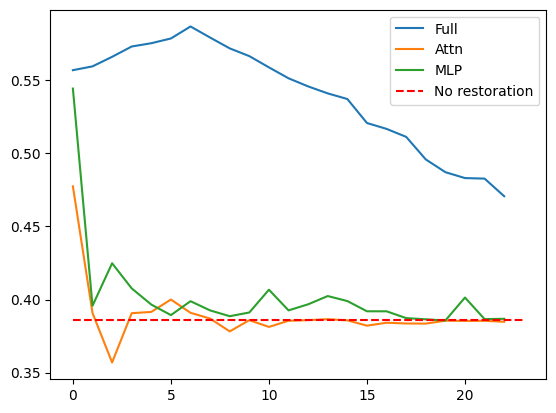

In [46]:
def run(
    prompt: str,
    subject_index: int,
    restore_layer: int,
    restore: str,
    clean_output,
    clean_states: Tuple[torch.Tensor],
    corrupt_states: Optional[Tuple[torch.Tensor]] = None,
):
    token_ids = tokenizer(
        prompt,
        add_special_tokens=True,
        return_tensors="pt",
    ).input_ids
    token_ids = torch.tensor(token_ids).unsqueeze(0)
    token_ids = token_ids.to(device)

    corrupt_output, _ = forward_model(
        token_ids,
        output_hidden_states=True,
        return_dict=True,
        corrupt=True,
        restore=restore,
        subject_index=subject_index,
        restore_layer=restore_layer,
        clean_hidden_states=clean_states,
        corrupt_hidden_states=corrupt_states,
    )

    eos_idx = torch.argmax(token_ids, dim=-1).item()
    # print(eos_idx)
    last_hidden_state = clean_output.last_hidden_state
    clean_text_embeds = clean_output.last_hidden_state[:, eos_idx, :]
    corrupt_text_embeds = corrupt_output.last_hidden_state[:, eos_idx, :]

    cos_sim = F.cosine_similarity(clean_text_embeds, corrupt_text_embeds, dim=-1)
    # print(cos_sim)
    return cos_sim.item()


templates = [
    "a {} in the snow",
    "a {} in the desert",
    "a {} in the forest",
    "a {} in the city",
    "a {} in the ocean",
    "a {} in the mountains",
    "a {} in the sky",
    "a {} in the park",
    "a {} in the garden",
    "a {} in the house",
    "a {} running",
    "a {} walking",
    "a {} sitting",
    "a {} sleeping",
]
prompts = []
for c in ("dog", "cat"):
    prompts += [t.format(c) for t in templates]
subject_index = 2

prompts = []
for c in ("dog", "cat"):
    prompts += [t.format(c) for t in IMAGENET_TEMPLATES_SMALL]
subject_index = None


full_results = {}
attn_results = {}
mlp_results = {}
corrupt_results = []
for prompt in prompts:
    token_ids = tokenizer(
        prompt,
        add_special_tokens=True,
        return_tensors="pt",
    ).input_ids
    token_ids = torch.tensor(token_ids).unsqueeze(0)
    token_ids = token_ids.to(device)
    eos_idx = torch.argmax(token_ids, dim=-1).item()
    subject_index = eos_idx - 1 if subject_index is None else subject_index

    clean_output, clean_states = forward_model(
        token_ids,
        output_hidden_states=True,
        return_dict=True,
    )
    corrupt_output, corrupt_states = forward_model(
        token_ids,
        output_hidden_states=True,
        return_dict=True,
        corrupt=True,
        subject_index=subject_index,
        restore="none",
    )
    corrupt_sim = (
        F.cosine_similarity(
            clean_output.last_hidden_state[:, eos_idx, :],
            corrupt_output.last_hidden_state[:, eos_idx, :],
            dim=-1,
        )
        .cpu()
        .item()
    )
    corrupt_results.append(corrupt_sim)

    for l in range(23):
        cos_sim = run(
            prompt=prompt,
            subject_index=subject_index,
            restore_layer=l,
            restore="full",
            clean_output=clean_output,
            clean_states=clean_states,
            corrupt_states=corrupt_states,
        )
        if l not in full_results:
            full_results[l] = []
        full_results[l].append(cos_sim)

        cos_sim = run(
            prompt=prompt,
            subject_index=subject_index,
            restore_layer=l,
            restore="attn",
            clean_output=clean_output,
            clean_states=clean_states,
            corrupt_states=corrupt_states,
        )
        if l not in attn_results:
            attn_results[l] = []
        attn_results[l].append(cos_sim)

        cos_sim = run(
            prompt=prompt,
            subject_index=subject_index,
            restore_layer=l,
            restore="mlp",
            clean_output=clean_output,
            clean_states=clean_states,
            corrupt_states=corrupt_states,
        )
        if l not in mlp_results:
            mlp_results[l] = []
        mlp_results[l].append(cos_sim)

for l in attn_results.keys():
    full_results[l] = sum(full_results[l]) / len(full_results[l])
    attn_results[l] = sum(attn_results[l]) / len(attn_results[l])
    mlp_results[l] = sum(mlp_results[l]) / len(mlp_results[l])
corrupt_sim = sum(corrupt_results) / len(corrupt_results)

plt.plot(full_results.keys(), full_results.values(), label="Full")
plt.plot(attn_results.keys(), attn_results.values(), label="Attn")
plt.plot(mlp_results.keys(), mlp_results.values(), label="MLP")
# plt.ylim([0, 1.05])
plt.hlines([corrupt_sim], 0, 23, color="red", linestyle="--", label="No restoration")
plt.legend()

# SANA (Gemma2)

In [4]:
from transformers import AutoTokenizer, Gemma2Model
from diffusers import (
    AutoencoderDC,
    FlowMatchEulerDiscreteScheduler,
    SanaTransformer2DModel,
)

MODEL = "Efficient-Large-Model/SANA1.5_1.6B_1024px_diffusers"

tokenizer = AutoTokenizer.from_pretrained(MODEL, subfolder="tokenizer")
text_encoder = Gemma2Model.from_pretrained(MODEL, subfolder="text_encoder").to(device)

embedding = text_encoder.get_input_embeddings().weight.data
std = embedding.std(dim=1).mean()
print(std)

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  2.36it/s]


tensor(0.0369, device='cuda:0')


In [ ]:
def forward_layer(
    self,
    hidden_states: torch.Tensor,
    attention_mask: torch.Tensor,
    position_ids: Optional[torch.LongTensor] = None,
    past_key_value: Optional[Cache] = None,
    output_attentions: Optional[bool] = False,
    use_cache: Optional[bool] = False,
    cache_position: Optional[torch.LongTensor] = None,
    last_cache_position: int = 0,
    *,
    subject_index: int = -1,
    restore: str = "none",
    verbose: bool = False,
    clean_states: Optional[Tuple[torch.Tensor]] = None,
    corrupt_states: Optional[Tuple[torch.Tensor]] = None,
) -> Tuple[torch.FloatTensor]:
    """
    Args:
        hidden_states (`torch.FloatTensor`): input to the layer of shape `(batch, seq_len, embed_dim)`
        attention_mask (`torch.FloatTensor`): attention mask of size
            `(batch, 1, tgt_len, src_len)` where padding elements are indicated by very large negative values.
            `(config.encoder_attention_heads,)`.
        output_attentions (`bool`, *optional*):
            Whether or not to return the attentions tensors of all attention layers. See `attentions` under
            returned tensors for more detail.
    """
    residual = hidden_states

    hidden_states = self.layer_norm1(hidden_states)
    hidden_states, attn_weights = self.self_attn(
        hidden_states=hidden_states,
        attention_mask=attention_mask,
        causal_attention_mask=causal_attention_mask,
        output_attentions=output_attentions,
    )
    attn_states = hidden_states
    if restore == "attn":
        if verbose:
            print(f"Restore attention hidden states ({subject_index})")
        hidden_states[:, subject_index, :] = clean_states[0][:, subject_index, :]
        # hidden_states[:, 1:subject_index+1, :] = clean_states[0][:, 1:subject_index+1, :]
    hidden_states = residual + hidden_states

    residual = hidden_states
    hidden_states = self.layer_norm2(hidden_states)
    hidden_states = self.mlp(hidden_states)
    mlp_states = hidden_states
    if restore == "mlp":
        if verbose:
            print(f"Restore MLP hidden states ({subject_index})")
        hidden_states[:, subject_index, :] = clean_states[1][:, subject_index, :]
        # hidden_states[:, 1:subject_index+1, :] = clean_states[1][:, 1:subject_index+1, :]
    elif restore == "attn":
        if verbose:
            print(f"Restore attention hidden states ({subject_index})")
        hidden_states[:, subject_index, :] = corrupt_states[1][:, subject_index, :]
    hidden_states = residual + hidden_states

    full_states = hidden_states
    if restore == "full":
        if verbose:
            print(f"Restore full hidden states ({subject_index})")
        hidden_states[:, subject_index, :] = clean_states[2][:, subject_index, :]
        # hidden_states[:, 1:subject_index+1, :] = clean_states[2][:, 1:subject_index+1, :]

    outputs = (hidden_states,)

    if output_attentions:
        outputs += (attn_weights,)

    return outputs, (attn_states, mlp_states, full_states)


def forward_encoder(
    self,
    inputs_embeds,
    attention_mask: Optional[torch.Tensor] = None,
    causal_attention_mask: Optional[torch.Tensor] = None,
    output_attentions: Optional[bool] = None,
    output_hidden_states: Optional[bool] = None,
    *,
    subject_index: int = -1,
    restore: str = "none",
    restore_layer: int = -1,
    verbose: bool = False,
    clean_hidden_states: Optional[torch.Tensor] = None,
    corrupt_hidden_states: Optional[torch.Tensor] = None,
) -> BaseModelOutput:
    output_attentions = (
        output_attentions
        if output_attentions is not None
        else self.config.output_attentions
    )
    output_hidden_states = (
        output_hidden_states
        if output_hidden_states is not None
        else self.config.output_hidden_states
    )

    encoder_states = () if output_hidden_states else None
    all_attentions = () if output_attentions else None
    all_clean_states = []

    hidden_states = inputs_embeds
    for idx, encoder_layer in enumerate(self.layers):
        if output_hidden_states:
            encoder_states = encoder_states + (hidden_states,)
        if self.gradient_checkpointing and self.training:
            layer_outputs = self._gradient_checkpointing_func(
                encoder_layer.__call__,
                hidden_states,
                attention_mask,
                causal_attention_mask,
                output_attentions,
            )
        else:
            _restore = restore if idx == restore_layer else "none"
            if _restore != "none" and verbose:
                print(f"Restore hidden states (Layer {idx})")
            layer_outputs, clean_states = forward_layer(
                encoder_layer,
                hidden_states,
                attention_mask,
                causal_attention_mask,
                output_attentions=output_attentions,
                restore=_restore,
                subject_index=subject_index,
                verbose=verbose,
                clean_states=clean_hidden_states[idx]
                if clean_hidden_states is not None
                else None,
                corrupt_states=corrupt_hidden_states[idx]
                if corrupt_hidden_states is not None
                else None,
            )
            all_clean_states.append(clean_states)

        hidden_states = layer_outputs[0]

        if output_attentions:
            all_attentions = all_attentions + (layer_outputs[1],)

    if output_hidden_states:
        encoder_states = encoder_states + (hidden_states,)

    return BaseModelOutput(
        last_hidden_state=hidden_states,
        hidden_states=encoder_states,
        attentions=all_attentions,
    ), all_clean_states


def forward_model(
    input_ids: Optional[torch.Tensor] = None,
    attention_mask: Optional[torch.Tensor] = None,
    position_ids: Optional[torch.Tensor] = None,
    output_attentions: Optional[bool] = None,
    output_hidden_states: Optional[bool] = None,
    return_dict: Optional[bool] = None,
    *,
    subject_index: int = -1,
    corrupt: bool = False,
    restore: bool = False,
    restore_layer: int = -1,
    clean_hidden_states=None,
    corrupt_hidden_states=None,
):
    model = text_encoder.text_model

    input_shape = input_ids.size()
    input_ids = input_ids.view(-1, input_shape[-1])

    hidden_states = model.embeddings(input_ids=input_ids, position_ids=position_ids)
    if corrupt:
        generator = torch.Generator(device=hidden_states.device)
        generator.manual_seed(0)
        bsz, _, embed_dim = hidden_states.shape
        seq_len = subject_index
        noise = torch.randn(
            (bsz, seq_len, embed_dim),
            generator=generator,
            device=hidden_states.device,
        ).mul(3 * std)
        hidden_states[:, 1 : subject_index + 1, :] += noise

    # CLIP's text model uses causal mask, prepare it here.
    # https://github.com/openai/CLIP/blob/cfcffb90e69f37bf2ff1e988237a0fbe41f33c04/clip/model.py#L324
    causal_attention_mask = _create_4d_causal_attention_mask(
        input_shape, hidden_states.dtype, device=hidden_states.device
    )
    # expand attention_mask
    if attention_mask is not None:
        # [bsz, seq_len] -> [bsz, 1, tgt_seq_len, src_seq_len]
        attention_mask = _prepare_4d_attention_mask(attention_mask, hidden_states.dtype)

    encoder_outputs, clean_states = forward_encoder(
        self=model.encoder,
        inputs_embeds=hidden_states,
        attention_mask=attention_mask,
        causal_attention_mask=causal_attention_mask,
        output_attentions=output_attentions,
        output_hidden_states=output_hidden_states,
        subject_index=subject_index,
        restore=restore,
        restore_layer=restore_layer,
        clean_hidden_states=clean_hidden_states,
        corrupt_hidden_states=corrupt_hidden_states,
    )

    last_hidden_state = encoder_outputs[0]
    last_hidden_state = model.final_layer_norm(last_hidden_state)

    if model.eos_token_id == 2:
        # The `eos_token_id` was incorrect before PR #24773: Let's keep what have been done here.
        # A CLIP model with such `eos_token_id` in the config can't work correctly with extra new tokens added
        # ------------------------------------------------------------
        # text_embeds.shape = [batch_size, sequence_length, transformer.width]
        # take features from the eot embedding (eot_token is the highest number in each sequence)
        # casting to torch.int for onnx compatibility: argmax doesn't support int64 inputs with opset 14
        pooled_output = last_hidden_state[
            torch.arange(last_hidden_state.shape[0], device=last_hidden_state.device),
            input_ids.to(dtype=torch.int, device=last_hidden_state.device).argmax(
                dim=-1
            ),
        ]
    else:
        # The config gets updated `eos_token_id` from PR #24773 (so the use of exta new tokens is possible)
        pooled_output = last_hidden_state[
            torch.arange(last_hidden_state.shape[0], device=last_hidden_state.device),
            # We need to get the first position of `eos_token_id` value (`pad_token_ids` might equal to `eos_token_id`)
            (
                input_ids.to(dtype=torch.int, device=last_hidden_state.device)
                == model.eos_token_id
            )
            .int()
            .argmax(dim=-1),
        ]

    if not return_dict:
        return (last_hidden_state, pooled_output) + encoder_outputs[1:]

    return BaseModelOutputWithPooling(
        last_hidden_state=last_hidden_state,
        pooler_output=pooled_output,
        hidden_states=encoder_outputs.hidden_states,
        attentions=encoder_outputs.attentions,
    ), clean_states